# Level 4 — Basic Analysis & Visualization

## Objective

The objective of Level 4 is to perform basic analysis on the verified train schedule dataset and identify useful patterns related to train frequency, station coverage, journey duration, and route types.

### Analysis Areas

1. Train frequency analysis
2. Station frequency analysis
3. Journey duration analysis
4. Route type distribution
5. Basic data visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Level_3_Verified_Train_Schedule.csv")

df.head()

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance,Journey_Duration,Journey_Duration_Hours,Route_Type
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,1900-01-01 00:00:00,1900-01-01 10:25:00,0,0 days 01:45:00,1.750000,Medium
1,2,107,THVM,260,228,196,164,THIVIM,1,1900-01-01 11:06:00,1900-01-01 11:08:00,32,0 days 01:45:00,1.750000,Medium
2,3,107,KRMI,345,296,247,198,KARMALI,1,1900-01-01 11:28:00,1900-01-01 11:30:00,49,0 days 01:45:00,1.750000,Medium
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,1900-01-01 12:10:00,1900-01-01 00:00:00,78,0 days 01:45:00,1.750000,Medium
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,1900-01-01 00:00:00,1900-01-01 20:30:00,0,0 days 01:55:00,1.916667,Medium


In [3]:
df.shape

(186074, 15)

In [4]:
df.columns

Index(['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL',
       'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time',
       'Distance', 'Journey_Duration', 'Journey_Duration_Hours', 'Route_Type'],
      dtype='str')

In [5]:
train_frequency = (
    df.groupby("Train_No")["Station_Name"]
      .count()
      .sort_values(ascending=False)
      .reset_index(name="Station_Count")
)

train_frequency.head(10)

,Train_No,Station_Count
0,53041,118
1,13007,112
2,13049,111
3,58112,109
4,13008,108
5,53042,107
6,13050,106
7,58111,102
8,19019,98
9,13352,97


In [6]:
train_frequency["Station_Count"].describe()

count    11113.000000
mean        16.743814
std         12.993123
min          2.000000
25%          8.000000
50%         15.000000
75%         22.000000
max        118.000000
Name: Station_Count, dtype: float64

In [7]:
train_frequency.head(10)

,Train_No,Station_Count
0,53041,118
1,13007,112
2,13049,111
3,58112,109
4,13008,108
5,53042,107
6,13050,106
7,58111,102
8,19019,98
9,13352,97


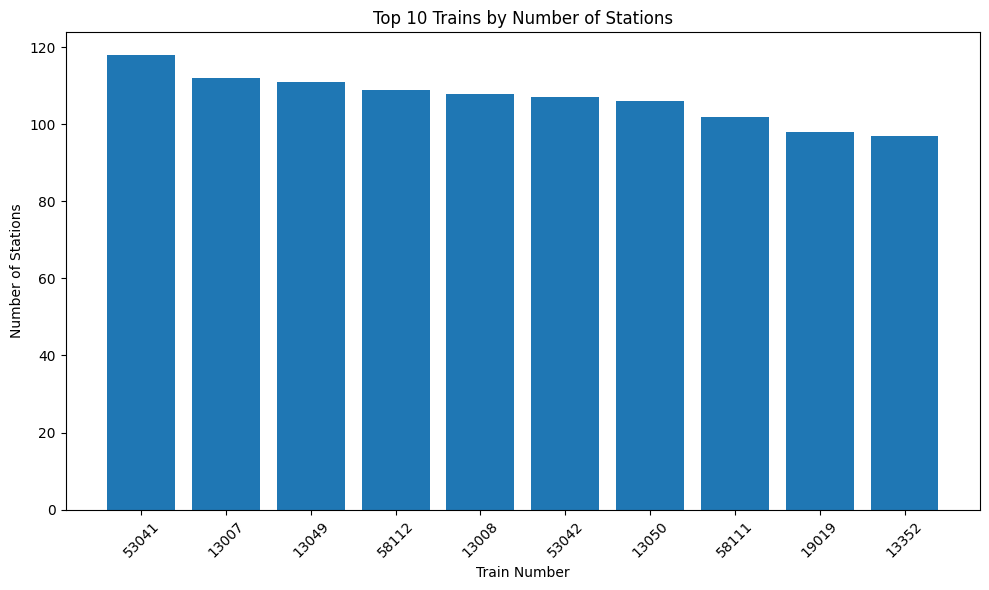

In [8]:
plt.figure(figsize=(10, 6))

plt.bar(
    train_frequency["Train_No"].head(10).astype(str),
    train_frequency["Station_Count"].head(10)
)

plt.xlabel("Train Number")
plt.ylabel("Number of Stations")
plt.title("Top 10 Trains by Number of Stations")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Finding

Train 53041 has the highest number of scheduled stations with 118 stations, followed by trains 13007 and 13049 with 112 and 111 stations respectively. This indicates that these trains cover routes with a relatively large number of scheduled station stops.

In [13]:
station_frequency = (
    df.groupby("Station_Name")["Train_No"]
      .nunique()
      .sort_values(ascending=False)
      .reset_index(name="Train_Frequency")
)

station_frequency.head(20)

,Station_Name,Train_Frequency
0,CST-MUMBAI,1027
1,KALYAN JN,828
2,THANE,796
3,SEALDAH,745
4,CHENNAI BEAC,738
5,HOWRAH JN.,699
6,DADAR,598
7,DUM DUM JN.,463
8,KURLA,462
9,TAMBARAM,434


In [17]:
top_stations = station_frequency.head(20)

top_stations

,Station_Name,Train_Frequency
0,CST-MUMBAI,1027
1,KALYAN JN,828
2,THANE,796
3,SEALDAH,745
4,CHENNAI BEAC,738
5,HOWRAH JN.,699
6,DADAR,598
7,DUM DUM JN.,463
8,KURLA,462
9,TAMBARAM,434


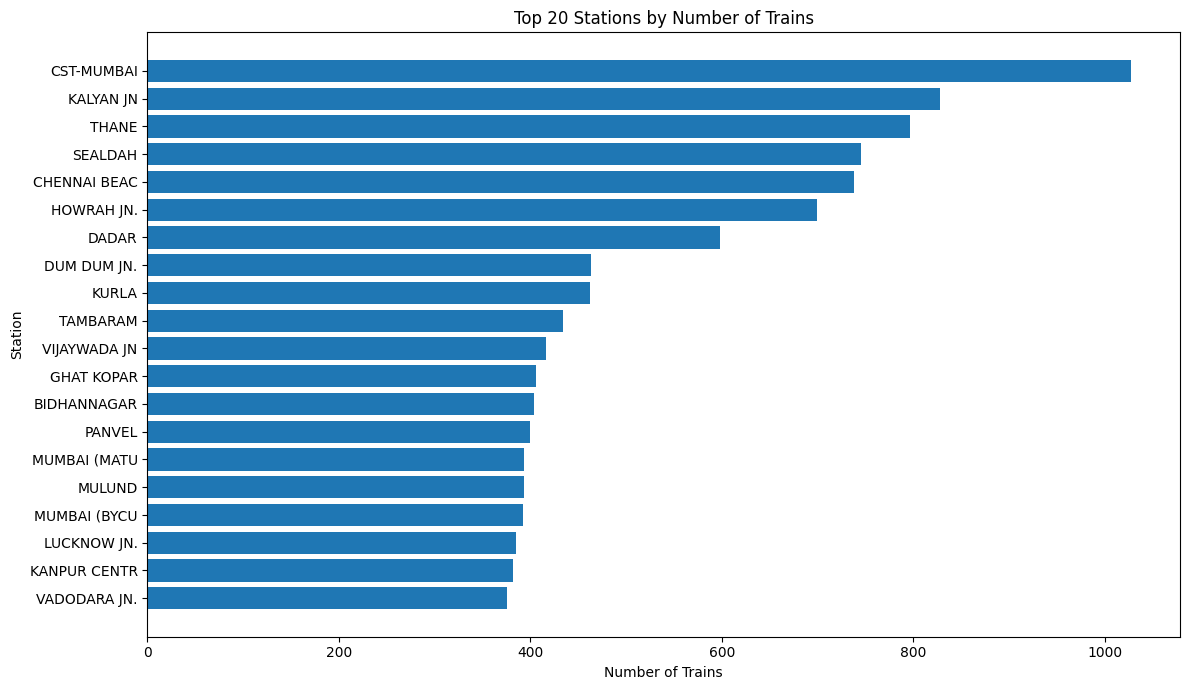

In [18]:
plt.figure(figsize=(12, 7))

plt.barh(
    top_stations["Station_Name"].iloc[::-1],
    top_stations["Train_Frequency"].iloc[::-1]
)

plt.xlabel("Number of Trains")
plt.ylabel("Station")
plt.title("Top 20 Stations by Number of Trains")

plt.tight_layout()
plt.show()

### Finding

The station frequency analysis identifies the stations served by the largest number of unique trains. These stations represent important railway locations with high train connectivity in the dataset.

In [19]:
route_type_counts = df["Route_Type"].value_counts()

route_type_counts

Route_Type
Medium     90169
Long       74448
Short      21140
Unknown      317
Name: count, dtype: int64

In [20]:
route_type_percentage = (
    df["Route_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

route_type_percentage

Route_Type
Medium     48.46
Long       40.01
Short      11.36
Unknown     0.17
Name: proportion, dtype: float64

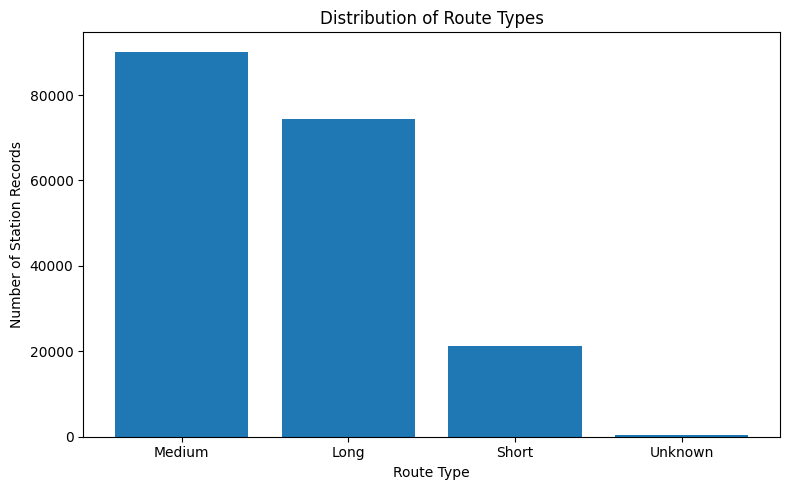

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    route_type_counts.index,
    route_type_counts.values
)

plt.xlabel("Route Type")
plt.ylabel("Number of Station Records")
plt.title("Distribution of Route Types")

plt.tight_layout()
plt.show()

### Finding

The route type analysis shows the distribution of Short, Medium, Long, and Unknown routes in the verified dataset. Medium routes represent the largest share of records, while Short and Long routes form the remaining major categories. Unknown records correspond to trains whose journey duration could not be reliably classified.

In [24]:
journey_summary = (
    df.groupby("Train_No")
      .agg(
          Start_Time=("Departure_Time", "first"),
          End_Time=("Arrival_time", "last"),
          Journey_Duration=("Journey_Duration", "first"),
          Journey_Duration_Hours=("Journey_Duration_Hours", "first"),
          Route_Type=("Route_Type", "first")
      )
      .reset_index()
)

journey_summary.head()

,Train_No,Start_Time,End_Time,Journey_Duration,Journey_Duration_Hours,Route_Type
0,107,1900-01-01 10:25:00,1900-01-01 12:10:00,0 days 01:45:00,1.750000,Medium
1,108,1900-01-01 20:30:00,1900-01-01 22:25:00,0 days 01:55:00,1.916667,Medium
2,128,1900-01-01 19:40:00,1900-01-01 17:45:00,0 days 22:05:00,22.083333,Long
3,290,1900-01-01 18:30:00,1900-01-01 02:30:00,0 days 08:00:00,8.000000,Long
4,401,1900-01-01 21:30:00,1900-01-01 10:00:00,0 days 12:30:00,12.500000,Long


In [25]:
route_train_counts = journey_summary["Route_Type"].value_counts()

route_train_counts

Route_Type
Medium     5537
Short      2787
Long       2783
Unknown       6
Name: count, dtype: int64

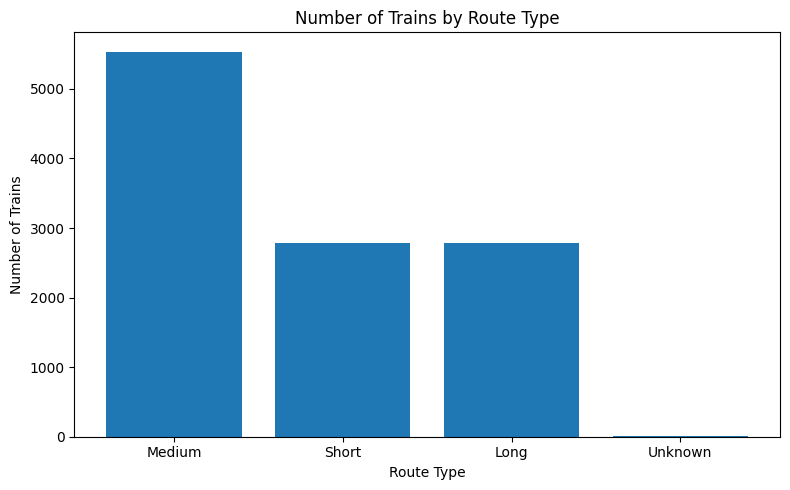

In [26]:
plt.figure(figsize=(8, 5))

plt.bar(
    route_train_counts.index,
    route_train_counts.values
)

plt.xlabel("Route Type")
plt.ylabel("Number of Trains")
plt.title("Number of Trains by Route Type")

plt.tight_layout()
plt.show()

### Finding

Among the 11,113 trains, Medium routes are the most common category with 5,537 trains, followed by Short routes with 2,787 trains and Long routes with 2,783 trains. Six trains have an Unknown route type because their calculated journey duration is zero and therefore could not be reliably classified.

In [27]:
journey_summary["Journey_Duration_Hours"].describe()

count    11113.000000
mean         4.600225
std          5.352782
min          0.000000
25%          1.016667
50%          2.200000
75%          6.083333
max         23.916667
Name: Journey_Duration_Hours, dtype: float64

### Finding

The average journey duration is approximately 4.60 hours, while the median journey duration is 2.20 hours. The maximum recorded journey duration is 23.92 hours. The mean being higher than the median indicates that longer journeys increase the overall average. Six trains have a duration of 0 hours and are classified as Unknown due to boundary/schedule data issues identified during Level 2 processing.

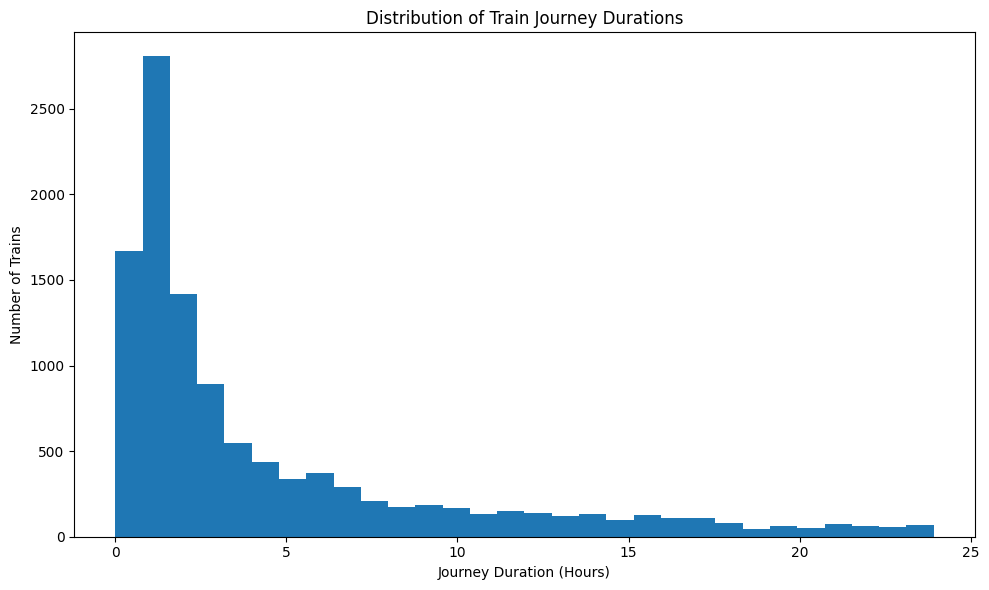

In [28]:
plt.figure(figsize=(10, 6))

plt.hist(
    journey_summary["Journey_Duration_Hours"],
    bins=30
)

plt.xlabel("Journey Duration (Hours)")
plt.ylabel("Number of Trains")
plt.title("Distribution of Train Journey Durations")

plt.tight_layout()
plt.show()

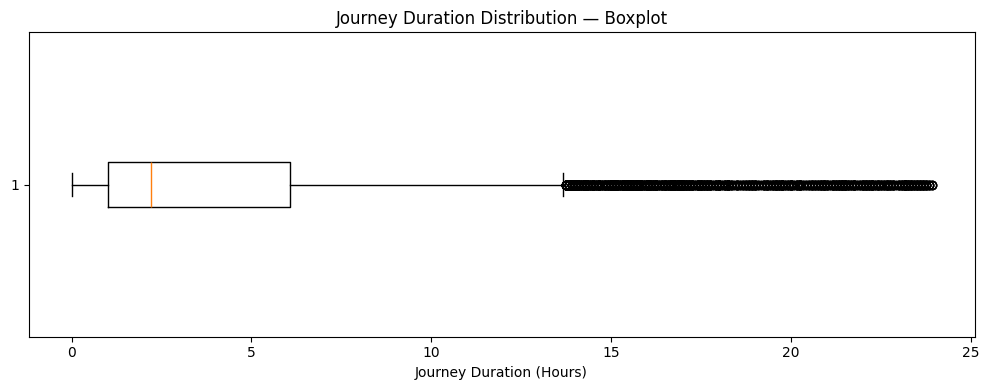

In [29]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    journey_summary["Journey_Duration_Hours"],
    vert=False
)

plt.xlabel("Journey Duration (Hours)")
plt.title("Journey Duration Distribution — Boxplot")

plt.tight_layout()
plt.show()

In [30]:
df["Distance"].describe()

count    186074.000000
mean        281.353838
std         483.743964
min           0.000000
25%          23.000000
50%          73.000000
75%         291.000000
max        4260.000000
Name: Distance, dtype: float64

### Finding

The Distance column contains 186,074 records with an average distance of 281.35 and a median of 73. The maximum recorded distance is 4,260. The mean is substantially higher than the median, indicating a right-skewed distribution caused by longer-distance train routes.

In [35]:
df["Distance"].isna().sum()

np.int64(0)

In [36]:
train_distance = (
    df.groupby("Train_No")["Distance"]
      .max()
      .reset_index(name="Total_Distance")
      .sort_values("Total_Distance", ascending=False)
)

train_distance.head(10)

,Train_No,Total_Distance
1934,15905,4260
1935,15906,4256
36,2515,3939
899,12507,3932
907,12515,3932
908,12516,3930
900,12508,3930
2021,16317,3769
2022,16318,3765
2117,16687,3663


### Finding

Train 15905 has the longest recorded route distance at 4,260, followed by Train 15906 at 4,256. Several other trains exceed 3,600 in route distance, indicating substantial variation in route coverage across the dataset.

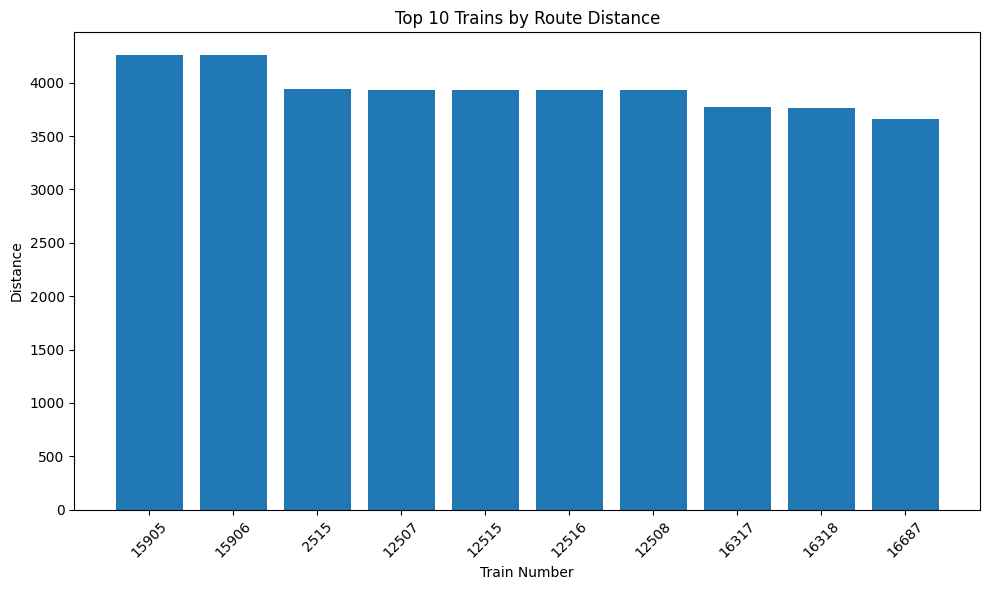

In [38]:
top_distance = train_distance.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_distance["Train_No"].astype(str),
    top_distance["Total_Distance"]
)

plt.xlabel("Train Number")
plt.ylabel("Distance")
plt.title("Top 10 Trains by Route Distance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
journey_analysis = journey_summary.merge(
    train_distance,
    on="Train_No",
    how="left"
)

journey_analysis.head()

,Train_No,Start_Time,End_Time,Journey_Duration,Journey_Duration_Hours,Route_Type,Total_Distance
0,107,1900-01-01 10:25:00,1900-01-01 12:10:00,0 days 01:45:00,1.750000,Medium,78
1,108,1900-01-01 20:30:00,1900-01-01 22:25:00,0 days 01:55:00,1.916667,Medium,83
2,128,1900-01-01 19:40:00,1900-01-01 17:45:00,0 days 22:05:00,22.083333,Long,978
3,290,1900-01-01 18:30:00,1900-01-01 02:30:00,0 days 08:00:00,8.000000,Long,2694
4,401,1900-01-01 21:30:00,1900-01-01 10:00:00,0 days 12:30:00,12.500000,Long,1618


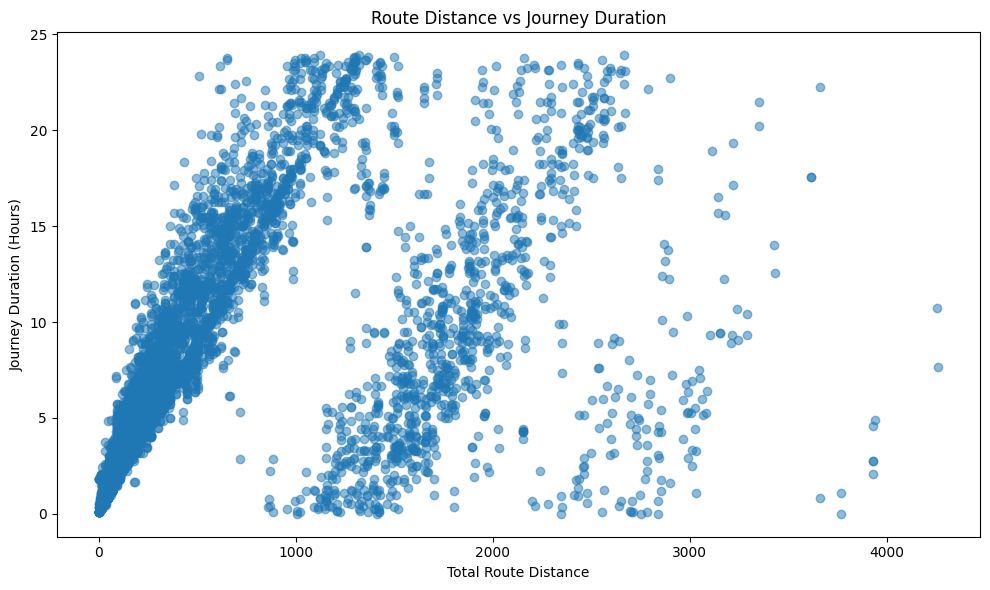

In [40]:
plt.figure(figsize=(10, 6))

plt.scatter(
    journey_analysis["Total_Distance"],
    journey_analysis["Journey_Duration_Hours"],
    alpha=0.5
)

plt.xlabel("Total Route Distance")
plt.ylabel("Journey Duration (Hours)")
plt.title("Route Distance vs Journey Duration")

plt.tight_layout()
plt.show()

In [41]:
correlation = journey_analysis[
    ["Total_Distance", "Journey_Duration_Hours"]
].corr()

correlation

,Total_Distance,Journey_Duration_Hours
Total_Distance,1.0000,0.6357
Journey_Duration_Hours,0.6357,1.0000


In [42]:
correlation_value = journey_analysis[
    "Total_Distance"
].corr(
    journey_analysis["Journey_Duration_Hours"]
)

print("Correlation:", correlation_value)

Correlation: 0.6357004122213629


### Finding

The correlation between total route distance and journey duration is approximately 0.636, indicating a moderate positive relationship. In general, trains covering longer distances tend to have longer journey durations. However, the relationship is not perfect, suggesting that factors other than distance also influence journey duration.

# Level 4 — Key Findings

### 1. Train Frequency
Train 53041 has the highest number of scheduled station stops, with 118 stations.

### 2. Station Frequency
The station frequency analysis identifies the stations served by the largest number of unique trains, highlighting important railway locations with high connectivity.

### 3. Route Type
Among 11,113 trains, Medium routes are the most common with 5,537 trains, followed by Short routes with 2,787 and Long routes with 2,783. Six trains are classified as Unknown.

### 4. Journey Duration
The average journey duration is 4.60 hours, while the median is 2.20 hours. The maximum recorded journey duration is 23.92 hours.

### 5. Distance
The average recorded distance is 281.35, while the median is 73. The maximum recorded distance is 4,260.

### 6. Distance vs Journey Duration
The correlation between route distance and journey duration is 0.636, indicating a moderate positive relationship. Longer routes generally tend to require longer journey durations.